# 03 - Concentração e entrega

Case Olist | Tech Challenge Fase 1

Aluno: Evanio Alves Carvalho

O notebook 02 terminou com duas coisas em aberto:

- a receita está muito presa a São Paulo, que sozinho faz 37% do total
- o crescimento parou porque o cliente parou de vir, não porque faltou vendedor

Este notebook testa se as duas coisas têm a mesma causa. A pergunta é direta: a experiência de entrega
explica por que a Olist vende tanto em São Paulo e tão pouco no resto do país?

Se a resposta for sim, muda a recomendação para o investidor. Mercado que não compra é um problema sem
solução fácil. Entrega que não funciona é um problema de operação, e problema de operação se resolve com
investimento.

## Como o atraso é medido aqui

Esse detalhe muda o resultado, então prefiro deixar explícito.

A data prometida de entrega vem sem hora na base, sempre meia-noite. A data real vem com hora cheia. Se as
duas forem comparadas direto, um pedido entregue no dia certo às 15h conta como atrasado. São 1.292 pedidos
nessa situação, e isso sozinho muda o atraso da base de 6,8% para 8,1%.

Por isso a comparação é feita só pela data, ignorando a hora. A coluna `atrasou` já vem pronta do
notebook 01, calculada assim, e é o critério que o grupo todo usa.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
os.makedirs('output', exist_ok=True)

In [2]:
fato_itens = pd.read_csv('data/processed/fato_itens.csv')
pedidos = pd.read_csv('data/processed/pedidos_tratados.csv')

for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    pedidos[col] = pd.to_datetime(pedidos[col])

print('itens:', len(fato_itens))
print('pedidos:', len(pedidos))

itens: 112650
pedidos: 99441


Uso o mesmo recorte do notebook 02 para a receita: janeiro de 2017 a agosto de 2018, sem `canceled` e
`unavailable`.

Para as contas de entrega, uso só os pedidos que foram realmente entregues, porque pedido que não chegou não
tem como ter tempo de entrega medido.

In [3]:
receita = fato_itens[
    (fato_itens['mes'].between('2017-01', '2018-08')) &
    (~fato_itens['order_status'].isin(['canceled', 'unavailable']))
].copy()

entregues = pedidos[
    (pedidos['mes'].between('2017-01', '2018-08')) &
    (pedidos['order_status'] == 'delivered') &
    (pedidos['order_delivered_customer_date'].notna())
].copy()

print('itens de receita:', len(receita))
print('pedidos entregues:', len(entregues))
print('atraso geral:', round(entregues['atrasou'].mean() * 100, 2), '%')

itens de receita: 111752
pedidos entregues: 96203
atraso geral: 6.79 %


## 1. Receita e entrega lado a lado

Montei uma tabela juntando as duas coisas por estado: quanto cada um representa da receita e quanto demora
para receber.

In [4]:
receita_uf = receita.groupby('customer_state')['receita'].sum().reset_index()
receita_uf['pct_receita'] = receita_uf['receita'] / receita_uf['receita'].sum() * 100

entrega_uf = entregues.groupby('customer_state').agg(
    dias_entrega=('dias_entrega', 'mean'),
    pct_atraso=('atrasou', 'mean'),
    pedidos=('order_id', 'nunique'),
).reset_index()
entrega_uf['pct_atraso'] = entrega_uf['pct_atraso'] * 100

uf = receita_uf.merge(entrega_uf, on='customer_state').sort_values('receita', ascending=False)
uf.to_csv('output/kpi_entrega_estado.csv', index=False)

uf.head(10).round(2)

,customer_state,receita,pct_receita,dias_entrega,pct_atraso,pedidos
25,SP,5863232.66,37.38,8.27,4.50,40399
18,RJ,2105549.64,13.43,14.84,12.14,12310
10,MG,1837646.07,11.72,11.52,4.59,11319
22,RS,873634.76,5.57,14.81,6.10,5327
17,PR,791701.89,5.05,11.51,4.06,4903
4,BA,605913.32,3.86,18.87,12.17,3253
23,SC,605522.98,3.86,14.47,8.23,3537
6,DF,350127.10,2.23,12.48,5.69,2074
8,GO,339389.70,2.16,15.16,6.56,1950
7,ES,322013.89,2.05,15.32,10.74,1992


Os dez estados que mais faturam são também os que recebem mais rápido. São Paulo lidera na receita com
37% e é o mais rápido de todos, com 8,3 dias.

In [5]:
print('--- os 8 mais lentos ---')
uf.sort_values('dias_entrega', ascending=False).head(8).round(2)

--- os 8 mais lentos ---


,customer_state,receita,pct_receita,dias_entrega,pct_atraso,pedidos
21,RR,9743.72,0.06,29.50,12.50,40
3,AP,16262.80,0.10,26.73,2.99,67
2,AM,27835.73,0.18,25.99,2.76,145
1,AL,96099.50,0.61,24.02,21.46,396
13,PA,216197.45,1.38,23.30,11.25,942
9,MA,149689.11,0.95,21.08,17.53,713
24,SE,72686.40,0.46,20.95,15.36,332
5,CE,272572.83,1.74,20.79,13.83,1273


E aqui o contraste fica evidente. Roraima leva 29 dias, três vezes e meia o tempo de São Paulo, e
responde por 0,06% da receita. Os estados mais lentos são todos irrelevantes em faturamento.

In [6]:
top5 = uf.head(5)
resto = uf.tail(len(uf) - 5)

print('top 5 estados')
print('  receita:', round(top5['pct_receita'].sum(), 1), '%')
print('  entrega média:', round((top5['dias_entrega'] * top5['pedidos']).sum() / top5['pedidos'].sum(), 1), 'dias')
print()
print('outros', len(resto), 'estados')
print('  receita:', round(resto['pct_receita'].sum(), 1), '%')
print('  entrega média:', round((resto['dias_entrega'] * resto['pedidos']).sum() / resto['pedidos'].sum(), 1), 'dias')

top 5 estados
  receita: 73.1 %
  entrega média: 10.5 dias

outros 22 estados
  receita: 26.9 %
  entrega média: 17.3 dias


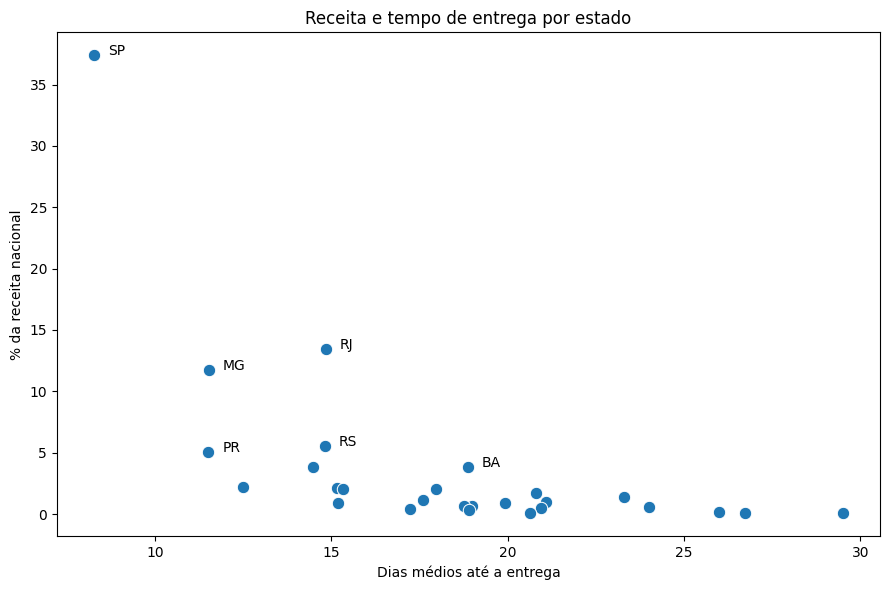

In [7]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=uf, x='dias_entrega', y='pct_receita', s=80)

for _, linha in uf.head(6).iterrows():
    plt.text(linha['dias_entrega'] + 0.4, linha['pct_receita'], linha['customer_state'], fontsize=10)

plt.title('Receita e tempo de entrega por estado')
plt.xlabel('Dias médios até a entrega')
plt.ylabel('% da receita nacional')
plt.tight_layout()
plt.savefig('output/chart_10_receita_x_entrega.png', dpi=150)
plt.show()

O gráfico mostra bem: São Paulo fica sozinho no canto, entregando rápido e faturando muito, e todo o
resto se amontoa embaixo. Quanto mais para a direita, menos receita.

Isso é correlação, não prova de causa. São Paulo tem mais gente e mais renda, e isso explica parte da
diferença. Mas o padrão é forte o suficiente para dizer que a entrega faz parte da explicação.

In [8]:
correlacao = uf['dias_entrega'].corr(uf['pct_receita'])
print('correlação entre dias de entrega e participação na receita:', round(correlacao, 2))

correlação entre dias de entrega e participação na receita: -0.6


## 2. O atraso não acompanha a distância

Aqui apareceu uma coisa que eu não esperava.

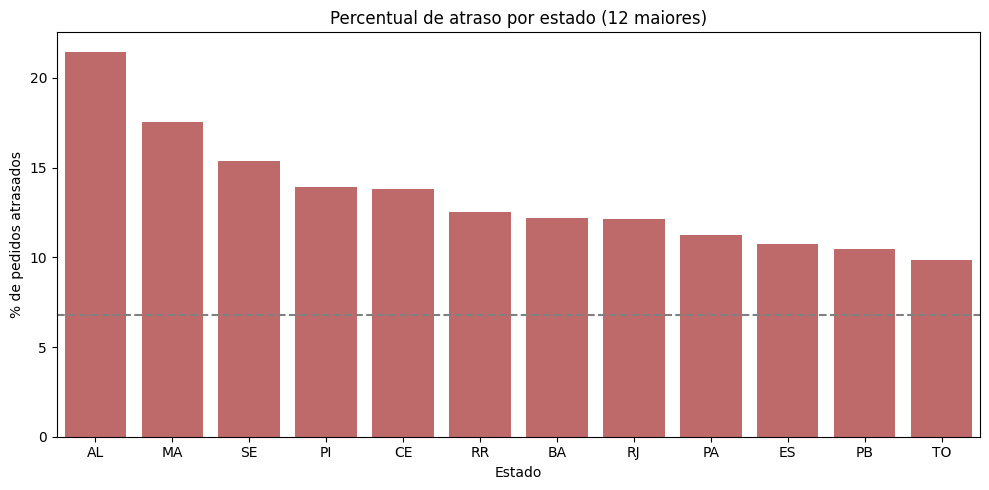

In [9]:
plt.figure(figsize=(10, 5))
ordenado = uf.sort_values('pct_atraso', ascending=False).head(12)
sns.barplot(data=ordenado, x='customer_state', y='pct_atraso', color='indianred')
plt.axhline(entregues['atrasou'].mean() * 100, color='gray', linestyle='--')
plt.title('Percentual de atraso por estado (12 maiores)')
plt.xlabel('Estado')
plt.ylabel('% de pedidos atrasados')
plt.tight_layout()
plt.savefig('output/chart_11_atraso_estado.png', dpi=150)
plt.show()

In [10]:
comparar = uf[uf['customer_state'].isin(['AL', 'RR', 'SP', 'MA', 'AP'])]
comparar[['customer_state', 'dias_entrega', 'pct_atraso', 'pct_receita']].round(2)

,customer_state,dias_entrega,pct_atraso,pct_receita
25,SP,8.27,4.50,37.38
9,MA,21.08,17.53,0.95
1,AL,24.02,21.46,0.61
3,AP,26.73,2.99,0.10
21,RR,29.50,12.50,0.06


Alagoas demora 24 dias e atrasa 21% das vezes. Roraima demora mais, 29 dias, e atrasa bem menos, 12%.
Amapá demora 27 dias e atrasa só 3%.

Ou seja, atrasar não é a mesma coisa que demorar. Atraso é entregar depois do que foi prometido. Um estado
pode demorar muito e não atrasar, desde que o prazo prometido já considere essa demora.

O caso de Alagoas indica prazo mal calibrado: a Olist promete ali um prazo que não consegue cumprir. Isso é
mais barato de resolver que melhorar a operação, porque basta ajustar a promessa.

## 3. Não é só o tempo, é o custo

Se a entrega é pior longe do Sudeste, o frete provavelmente também é mais caro. Fui medir.

Aqui tem uma armadilha de cálculo que vale mostrar, porque dá resultados bem diferentes.

In [11]:
receita['razao_item'] = receita['freight_value'] / receita['price']

frete_uf = receita.groupby('customer_state').agg(
    produto=('price', 'sum'),
    frete=('freight_value', 'sum'),
    media_das_razoes=('razao_item', 'mean'),
).reset_index()

frete_uf['agregado'] = frete_uf['frete'] / frete_uf['produto'] * 100
frete_uf['media_das_razoes'] = frete_uf['media_das_razoes'] * 100

frete_uf = frete_uf.merge(uf[['customer_state', 'pct_receita']], on='customer_state')
frete_uf.sort_values('agregado', ascending=False).head(8).round(1)

,customer_state,produto,frete,media_das_razoes,agregado,pct_receita
21,RR,7626.8,2116.9,58.0,27.8,0.1
9,MA,118587.4,31101.8,55.0,26.2,1.0
20,RO,46031.6,11392.1,59.5,24.7,0.4
2,AM,22356.8,5478.9,49.8,24.5,0.2
16,PI,86450.1,21069.3,50.1,24.4,0.7
24,SE,58635.4,14051.0,46.6,24.0,0.5
26,TO,49408.0,11695.9,50.1,23.7,0.4
0,AC,15983.0,3686.8,51.2,23.1,0.1


As duas colunas medem a mesma coisa de jeitos diferentes:

- agregado soma todo o frete e divide pela soma de todos os produtos. Responde "de cada R$ 100 vendidos em
  produto, quanto foi de frete".
- media_das_razoes calcula a proporção item a item e tira a média. Isso dá números bem maiores, porque um
  item de R$ 10 com frete de R$ 15 conta como 150% e pesa igual a uma venda grande.

Usei o agregado, porque é o que responde a pergunta de negócio sem inflar. Vale registrar isso, porque pelo
outro método os mesmos estados apareceriam com 50% a 60%, o que soa muito mais dramático e é fácil de
interpretar errado.

In [12]:
print('frete sobre produto, método agregado:')
for uf_nome in ['SP', 'RJ', 'MG', 'BA', 'MA', 'RR']:
    linha = frete_uf[frete_uf['customer_state'] == uf_nome].iloc[0]
    print(' ', uf_nome, '-', round(linha['agregado'], 1), '%')

frete sobre produto, método agregado:
  SP - 13.8 %
  RJ - 16.8 %
  MG - 17.1 %
  BA - 19.7 %
  MA - 26.2 %
  RR - 27.8 %


Em São Paulo o frete é 13,8% do valor do produto. No Maranhão e em Roraima passa de 26%, quase o dobro.

Somando as duas coisas, comprar fora do Sudeste custa mais caro e demora mais. Isso ajuda a explicar por que
os outros 22 estados juntos só fazem 27% da receita.

## 4. O cliente que teve atraso volta a comprar?

Essa é a pergunta que liga a entrega ao achado do notebook 02, o de que a receita parou porque o cliente
parou de vir. Se quem tem má experiência não volta, a entrega deixa de ser só um problema de satisfação e
passa a ser um problema de receita.

Peguei a primeira compra de cada cliente, vi se ela atrasou, e depois vi se aquele cliente voltou a comprar
alguma vez.

In [13]:
p = pedidos[~pedidos['order_status'].isin(['canceled', 'unavailable'])].copy()

p = p.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
p['ordem'] = p.groupby('customer_unique_id').cumcount() + 1

total_por_cliente = p.groupby('customer_unique_id')['order_id'].count().rename('total_pedidos')

primeira = p[p['ordem'] == 1].merge(total_por_cliente, on='customer_unique_id')
primeira = primeira[
    (primeira['order_status'] == 'delivered') &
    (primeira['order_delivered_customer_date'].notna())
].copy()
primeira['voltou'] = primeira['total_pedidos'] > 1

print('clientes com a primeira compra entregue:', len(primeira))
print('recompra geral:', round(primeira['voltou'].mean() * 100, 2), '%')

clientes com a primeira compra entregue: 93290
recompra geral: 3.02 %


Antes de comparar, um cuidado. Quem comprou pela primeira vez em agosto de 2018 quase não teve tempo de
voltar, porque a base termina ali. Se eu incluir essas pessoas, elas puxam a recompra para baixo sem motivo.

Por isso limitei a quem fez a primeira compra até fevereiro de 2018, garantindo pelo menos seis meses de
janela para todo mundo.

In [14]:
janela = primeira[primeira['order_purchase_timestamp'] < '2018-03-01']

comparacao = janela.groupby('atrasou').agg(
    clientes=('customer_unique_id', 'count'),
    recompra=('voltou', 'mean'),
).reset_index()
comparacao['recompra_pct'] = (comparacao['recompra'] * 100).round(2)

comparacao[['atrasou', 'clientes', 'recompra_pct']]

,atrasou,clientes,recompra_pct
0,False,51813,4.08
1,True,3674,3.16


In [15]:
no_prazo = comparacao[~comparacao['atrasou']]['recompra'].values[0]
atrasado = comparacao[comparacao['atrasou']]['recompra'].values[0]

print('primeira compra no prazo:', round(no_prazo * 100, 2), '%')
print('primeira compra atrasada:', round(atrasado * 100, 2), '%')
print()
print('diferença absoluta:', round((no_prazo - atrasado) * 100, 2), 'pontos percentuais')
print('queda relativa:', round((atrasado / no_prazo - 1) * 100, 1), '%')

primeira compra no prazo: 4.08 %
primeira compra atrasada: 3.16 %

diferença absoluta: 0.92 pontos percentuais
queda relativa: -22.6 %


Antes de concluir qualquer coisa, quis saber se essa diferença poderia ser só sorte da amostra. Fiz um
teste de qui-quadrado, que compara o que foi observado com o que seria esperado se atraso e recompra não
tivessem relação nenhuma.

In [16]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(janela['atrasou'], janela['voltou'])
chi2, p_valor, _, _ = chi2_contingency(tabela)

print(tabela)
print()
print('p-valor:', round(p_valor, 5))

voltou   False  True 
atrasou              
False    49700   2113
True      3558    116

p-valor: 0.00687


O p-valor deu 0,007, bem abaixo de 0,05. Então a diferença não é acaso, o atraso realmente reduz a
chance do cliente voltar.

Mas o tamanho do efeito precisa ser dito com honestidade. A queda é de 22% em termos relativos, o que
parece muito, mas em números absolutos é menos de 1 ponto percentual: de 4,08% para 3,16%.

O que isso quer dizer na prática: mesmo entregando tudo no prazo, cerca de 96% dos clientes não voltam. O
atraso piora um problema que já é grave por outro motivo. Consertar a entrega é necessário, mas sozinho não
resolve a retenção.

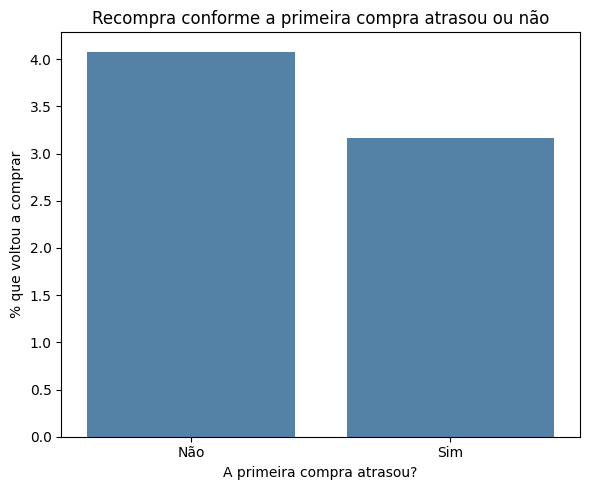

In [17]:
plt.figure(figsize=(6, 5))
sns.barplot(data=comparacao, x='atrasou', y='recompra_pct', color='steelblue')
plt.title('Recompra conforme a primeira compra atrasou ou não')
plt.xlabel('A primeira compra atrasou?')
plt.ylabel('% que voltou a comprar')
plt.xticks([0, 1], ['Não', 'Sim'])
plt.tight_layout()
plt.savefig('output/chart_12_recompra_atraso.png', dpi=150)
plt.show()

In [18]:
comparacao.to_csv('output/kpi_recompra_atraso.csv', index=False)
frete_uf.to_csv('output/kpi_frete_estado.csv', index=False)
print('indicadores salvos')

indicadores salvos


## 5. O que eu concluo

A entrega explica parte da concentração, mas não tudo.

Os cinco estados que fazem 73% da receita recebem em 8 a 15 dias. Os estados que quase não vendem esperam de
21 a 29 dias e ainda pagam quase o dobro de frete em proporção ao produto. Comprar fora do Sudeste é mais caro
e mais demorado, e isso ajuda a explicar por que 22 estados juntos somam só 27% do faturamento.

Não dá para dizer que a entrega é a causa única, porque São Paulo também concentra população e renda. Mas dá
para dizer que ela é parte do problema, e essa é a parte que a empresa consegue mudar.

Atrasar e demorar são coisas diferentes. Alagoas atrasa 21% das vezes entregando em 24 dias, enquanto
Roraima atrasa 12% entregando em 29. Onde o prazo prometido está mal calibrado, dá para melhorar a experiência
só ajustando a promessa, sem tocar na operação.

O atraso afasta o cliente, mas pouco. Quem teve a primeira compra atrasada volta 22% menos, e o teste
confirma que não é acaso. Só que a diferença absoluta é de 0,92 ponto percentual, porque quase ninguém volta
de qualquer jeito.

Essa última parte é importante para não vender uma conclusão maior do que o dado permite. Se alguém estimar
perda de receita assumindo que todo cliente insatisfeito teria voltado, vai superestimar muito, porque a
recompra da base inteira é de 4%. O cálculo honesto usa a diferença entre os dois grupos, não o valor cheio.

Juntando com o notebook 02: a receita parou de crescer porque faltou cliente, e o cliente é mais difícil
de conquistar exatamente onde entregar é caro e lento. Melhorar logística regional ataca as duas coisas ao
mesmo tempo. Mas como o atraso explica menos de 1 ponto da recompra, resolver só a entrega não vai criar uma
base fiel, e a retenção precisa ser atacada por outro caminho.